- Not Transformed Amount 
- Includes fine tuning with dropout and reguralization 

In [1]:
# Imports
###BEGIN library importing+
import tensorflow as tf
import matplotlib.pyplot as plt
###END library importing
from pathlib import Path
import tarfile
import urllib.request
import sys
import io
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn import set_config
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.svm import SVR
from sklearn.metrics import *
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import BaggingRegressor
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import (
    VotingRegressor,
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor)
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
from tensorflow.keras import Sequential, layers
import keras_tuner as kt

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.model_selection import train_test_split
from code_files.train import train, train_in_batches, grid_search
from code_files.data_preperation import prepare_for_train
import pandas as pd
import numpy as np

In [2]:
# Load Dataset
df_amazon = pd.read_csv("../dataset/eda_amazon_sales_report.csv")
df_amazon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117123 entries, 0 to 117122
Data columns (total 24 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Unnamed: 0                           117123 non-null  int64  
 1   Size                                 117123 non-null  int64  
 2   Qty                                  117123 non-null  int64  
 3   Amount                               117123 non-null  float64
 4   promotion-ids                        117123 non-null  int64  
 5   B2B                                  117123 non-null  int64  
 6   Status_Cancelled                     117123 non-null  bool   
 7   Status_Shipped                       117123 non-null  bool   
 8   Status_Shipped - Delivered to Buyer  117123 non-null  bool   
 9   Fulfilment_Amazon                    117123 non-null  bool   
 10  Fulfilment_Merchant                  117123 non-null  bool   
 11  ship-service-

In [3]:
# Split and Prepare for train
dftrain, dftest = train_test_split(df_amazon, test_size=0.1, random_state=42)
Xtrain_prepared, ytrain_prepared, Xtest_prepared, ytest_prepared = prepare_for_train(dftrain, dftest)

Xtrain_prepared, Xdev_prepared, ytrain_prepared, ydev_prepared = train_test_split(Xtrain_prepared, ytrain_prepared,
                                                                                  test_size=0.2, random_state=42)


print("Train shape: ", Xtrain_prepared.shape, ytrain_prepared.shape)
print("Dev shape: ", Xdev_prepared.shape, ydev_prepared.shape)
print("Test shape: ", Xtest_prepared.shape, ytest_prepared.shape)

Train shape:  (83216, 7) (83216,)
Dev shape:  (20804, 7) (20804,)
Test shape:  (11713, 7) (11713,)


In [4]:
# Random Search Hypertuning 

import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, regularizers

# Helping functions
def build_model(hp):

    n_hidden = hp.Int("n_hidden", min_value=2, max_value=10, default=2)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=0.9,
                                      sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam", "adagrad", "rms", "adadelta", 
                                               "adamax", "nadam"])

    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == "adagrad":
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=learning_rate)
    elif optimizer == "rms": 
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer == "adadelta":
        optimizer = tf.keras.optimizers.Adadelta(learning_rate=learning_rate)
    elif optimizer == "adamax":
        optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
    elif optimizer == "ftrl":
        optimizer = tf.keras.optimizers.Ftrl(learning_rate=learning_rate)
    elif optimizer == "nadam": 
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())

    for _ in range(n_hidden):
        # Adding L2 regularization to Dense layers
        model.add(tf.keras.layers.Dense(
            units = hp.Int("n_neurons", min_value=100, max_value=900, step=50, sampling="log"),
            activation=hp.Choice("activation", values=["relu", "tanh", "selu", "linear", "swish", "softplus", "exponential"]),
            kernel_regularizer=regularizers.l2(hp.Float("l2_reg", min_value=1e-5, max_value=1e-1, sampling="log"))  # Regularization added
        ))
        model.add(layers.Dropout(rate=hp.Float("dropout_rate", min_value=0.01, max_value=0.9, step=0.05)))

    model.add(layers.Dense(1, activation='linear'))
    model.compile(
        loss='mse',
        optimizer=optimizer,
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

########################

# Define parameter grid
out_folder = "amazon"
rnd_search_folder = "rnd_search"
random_search_tuner = kt.RandomSearch(
    build_model, objective="loss", max_trials=25, overwrite=True,
    directory=out_folder, project_name=rnd_search_folder, seed=42
)

random_search_tuner.search(Xtrain_prepared, ytrain_prepared, epochs=5, batch_size=64,
                           validation_data=(Xdev_prepared, ydev_prepared))

random_search_tuner.search_space_summary()

random_search_tuner.results_summary()

# Build the best model and retrain it
top3_models = random_search_tuner.get_best_models(num_models=3)

top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)

for i in range(len(top3_params)):
    print(top3_params[i].values)




Trial 25 Complete [00h 00m 08s]
loss: 115117.46875

Best loss So Far: 76044.421875
Total elapsed time: 00h 04m 05s
Search space summary
Default search space size: 7
n_hidden (Int)
{'default': 2, 'conditions': [], 'min_value': 2, 'max_value': 10, 'step': 1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.9, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'sgd', 'conditions': [], 'values': ['sgd', 'adam', 'adagrad', 'rms', 'adadelta', 'adamax', 'nadam'], 'ordered': False}
n_neurons (Int)
{'default': None, 'conditions': [], 'min_value': 100, 'max_value': 900, 'step': 50, 'sampling': 'log'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'selu', 'linear', 'swish', 'softplus', 'exponential'], 'ordered': False}
l2_reg (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
dropout_rate (Float)
{'default': 0.01, 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adadelta', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


{'n_hidden': 6, 'learning_rate': 0.008209618290737282, 'optimizer': 'adadelta', 'n_neurons': 100, 'activation': 'relu', 'l2_reg': 5.939437813279243e-05, 'dropout_rate': 0.01}
{'n_hidden': 2, 'learning_rate': 0.009276416723841687, 'optimizer': 'adam', 'n_neurons': 100, 'activation': 'swish', 'l2_reg': 0.04514107426881946, 'dropout_rate': 0.060000000000000005}
{'n_hidden': 2, 'learning_rate': 0.00462287884982147, 'optimizer': 'nadam', 'n_neurons': 100, 'activation': 'softplus', 'l2_reg': 0.0003036527652974287, 'dropout_rate': 0.16000000000000003}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 15 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
# Build model 
from tensorflow.keras import regularizers

optimizer1 = tf.keras.optimizers.Adadelta(learning_rate=0.008209618290737282)

model1 = tf.keras.Sequential()

model1.add(tf.keras.layers.Input(shape=(7,)))  

model1.add(tf.keras.layers.Dense(100, activation="relu", kernel_regularizer=regularizers.l2(5.939437813279243e-05)))
model1.add(tf.keras.layers.Dropout(0.01))
model1.add(tf.keras.layers.Dense(100, activation="relu", kernel_regularizer=regularizers.l2(5.939437813279243e-05)))
model1.add(tf.keras.layers.Dropout(0.01))
model1.add(tf.keras.layers.Dense(100, activation="relu", kernel_regularizer=regularizers.l2(5.939437813279243e-05)))
model1.add(tf.keras.layers.Dropout(0.01))
model1.add(tf.keras.layers.Dense(100, activation="relu", kernel_regularizer=regularizers.l2(5.939437813279243e-05)))
model1.add(tf.keras.layers.Dropout(0.01))
model1.add(tf.keras.layers.Dense(100, activation="relu", kernel_regularizer=regularizers.l2(5.939437813279243e-05)))
model1.add(tf.keras.layers.Dropout(0.01))
model1.add(tf.keras.layers.Dense(100, activation="relu", kernel_regularizer=regularizers.l2(5.939437813279243e-05)))
model1.add(tf.keras.layers.Dropout(0.01))


model1.add(tf.keras.layers.Dense(1, activation="linear", kernel_regularizer=regularizers.l2(5.939437813279243e-05)))

model1.compile(loss="mse", optimizer=optimizer1, metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Print the model summary
model1.summary()

# Train the model
history = model1.fit(
    Xtrain_prepared, ytrain_prepared,
    epochs=500,     
    batch_size=64,      
    validation_data=(Xdev_prepared, ydev_prepared)
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,401 (200.79 KB)

 Trainable params: 51,401 (200.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 300822.9688 - root_mean_squared_error: 537.1172 - val_loss: 77782.3750 - val_root_mean_squared_error: 278.8948
Epoch 2/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 77098.7266 - root_mean_squared_error: 277.6627 - val_loss: 77653.0234 - val_root_mean_squared_error: 278.6629
Epoch 3/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 76340.4922 - root_mean_squared_error: 276.2955 - val_loss: 77728.8359 - val_root_mean_squared_error: 278.7989
Epoch 4/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 76311.6484 - root_mean_squared_error: 276.2362 - val_loss: 77607.4297 - val_root_mean_squared_error: 278.5811
Epoch 5/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 76401.5859 - root_mean_squared_error: 276.4029 - val_loss: 77592.1953 - val_root_mean_squared_error: 278.5536
Epoch 6/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 76951.9844 - root_mean_squared_error: 277.4002 - val_loss: 77643.6953 -

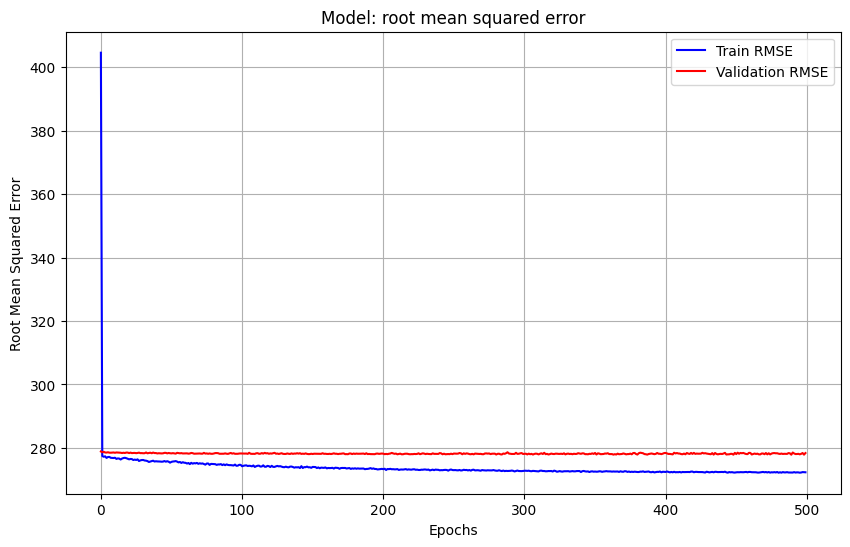

In [6]:
# Display RMSE error for Train and Validation set 

epochs = list(range(800, 2000))
plt.figure(figsize=(10, 6))
plt.plot(history.history['root_mean_squared_error'],label='Train RMSE',color='blue')
plt.plot(history.history['val_root_mean_squared_error'],label='Validation RMSE',color='red')
plt.title(f'Model: root mean squared error')
plt.xlabel('Epochs')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf

y_pred = model1.predict(Xtest_prepared)

# MAE (Mean Absolute Error)
mae = mean_absolute_error(ytest_prepared, y_pred)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(ytest_prepared, y_pred))

# R² (R-squared)
r2 = r2_score(ytest_prepared, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")


367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step
MAE: 209.894930382195
RMSE: 274.3141468885644
R²: 0.06006951871907118
